Introduction

The video game industry generates billions of dollars every year and PlayStation is one of the most successful gaming platforms. Understanding the factors that influence game sales can help developers and publishers make better decisions.

This project analyzes PlayStation game sales across PS3, PS4, and PS5 platforms using statistical analysis, visualization, and preprocessing techniques.

Description

Rows:
10,000+ game records

Features:
15–20 features including:
- Game Name
- Platform
- Release Year
- Genre
- Publisher
- Developer
- Critic Score
- User Score
- NA Sales
- EU Sales
- JP Sales
- Global Sales

Research Questions

1. What factors mostly influence video game sales on PlayStation platforms?
2. How do sales patterns differ across PlayStation generations (PS3, PS4, PS5)?
3. Can video game sales be predicted using game metadata?

Novelty Contribution

This study analyzes how games perform across multiple PlayStation generations and applies machine learning techniques to identify key factors influencing video game success. It also compares how different platforms and genres perform to reveal market trends in the PlayStation ecosystem.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv('/kaggle/input/datasets/furqan776/csv-file/PlayStation Sales and Metadata (PS3PS4PS5) (Oct 2025).csv')

df.head()

,Game,Console,Name,Publisher,Developer,Total Shipped,Total Sales,NA Sales,PAL Sales,Japan Sales,Other Sales,Release Date,Last Update,rating,ratings_count,metacritic,genres,platforms
0,PS3_Grand Theft Auto V,PS3,Grand Theft Auto V,Rockstar Games,Rockstar North,0.0,20320000.0,6370000.0,9850000.0,990000.0,3120000.0,2013-09-17,NaN,4.47,7225.0,92.0,Action,"PC, PlayStation 5, Xbox One, PlayStation 4, Xb..."
1,PS4_Grand Theft Auto V,PS4,Grand Theft Auto V,Rockstar Games,Rockstar North,0.0,19390000.0,6060000.0,9710000.0,600000.0,3020000.0,2014-11-18,2018-01-03,4.47,7225.0,92.0,Action,"PC, PlayStation 5, Xbox One, PlayStation 4, Xb..."
2,PS4_Call of Duty: Black Ops 3,PS4,Call of Duty: Black Ops 3,Activision,Treyarch,0.0,15090000.0,6180000.0,6050000.0,410000.0,2440000.0,2015-11-06,2018-01-14,NaN,NaN,NaN,NaN,NaN
3,PS4_Red Dead Redemption 2,PS4,Red Dead Redemption 2,Rockstar Games,Rockstar Games,0.0,13940000.0,5260000.0,6210000.0,210000.0,2260000.0,2018-10-26,2018-11-02,4.59,5357.0,96.0,Action,"PC, Xbox One, PlayStation 4"
4,PS3_Call of Duty: Black Ops II,PS3,Call of Duty: Black Ops II,Activision,Treyarch,0.0,13800000.0,4990000.0,5880000.0,650000.0,2280000.0,2012-11-13,NaN,3.96,1417.0,74.0,"Shooter, Action","PC, Xbox One, Xbox 360, PlayStation 3, Wii U"


In [3]:
df.shape

(4963, 18)

In [4]:
df.columns

Index(['Game', 'Console', 'Name', 'Publisher', 'Developer', 'Total Shipped',
       'Total Sales', 'NA Sales', 'PAL Sales', 'Japan Sales', 'Other Sales',
       'Release Date', 'Last Update', 'rating', 'ratings_count', 'metacritic',
       'genres', 'platforms'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4963 entries, 0 to 4962
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Game           4963 non-null   object 
 1   Console        4963 non-null   object 
 2   Name           4963 non-null   object 
 3   Publisher      4963 non-null   object 
 4   Developer      4963 non-null   object 
 5   Total Shipped  4963 non-null   float64
 6   Total Sales    4963 non-null   float64
 7   NA Sales       4963 non-null   float64
 8   PAL Sales      4963 non-null   float64
 9   Japan Sales    4963 non-null   float64
 10  Other Sales    4963 non-null   float64
 11  Release Date   3526 non-null   object 
 12  Last Update    2801 non-null   object 
 13  rating         2847 non-null   float64
 14  ratings_count  2847 non-null   float64
 15  metacritic     1530 non-null   float64
 16  genres         2803 non-null   object 
 17  platforms      2847 non-null   object 
dtypes: float

In [6]:
df.describe()

,Total Shipped,Total Sales,NA Sales,PAL Sales,Japan Sales,Other Sales,rating,ratings_count,metacritic
count,4.963000e+03,4.963000e+03,4.963000e+03,4.963000e+03,4.963000e+03,4.963000e+03,2847.000000,2847.000000,1530.000000
mean,9.352005e+04,3.008906e+05,1.178199e+05,1.170482e+05,2.178723e+04,4.426154e+04,2.762455,269.917106,73.826144
std,8.977504e+05,1.055158e+06,4.052999e+05,4.946509e+05,8.250273e+04,1.639967e+05,1.531923,618.110338,11.532527
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,21.000000
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.400000,8.000000,68.000000
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.380000,44.000000,76.000000
75%,0.000000e+00,1.600000e+05,7.000000e+04,3.000000e+04,0.000000e+00,2.000000e+04,3.830000,205.500000,82.000000
max,2.269000e+07,2.032000e+07,6.370000e+06,9.850000e+06,2.170000e+06,3.120000e+06,4.760000,7225.000000,97.000000


In [7]:
df.isnull().sum()

Game                0
Console             0
Name                0
Publisher           0
Developer           0
Total Shipped       0
Total Sales         0
NA Sales            0
PAL Sales           0
Japan Sales         0
Other Sales         0
Release Date     1437
Last Update      2162
rating           2116
ratings_count    2116
metacritic       3433
genres           2160
platforms        2116
dtype: int64

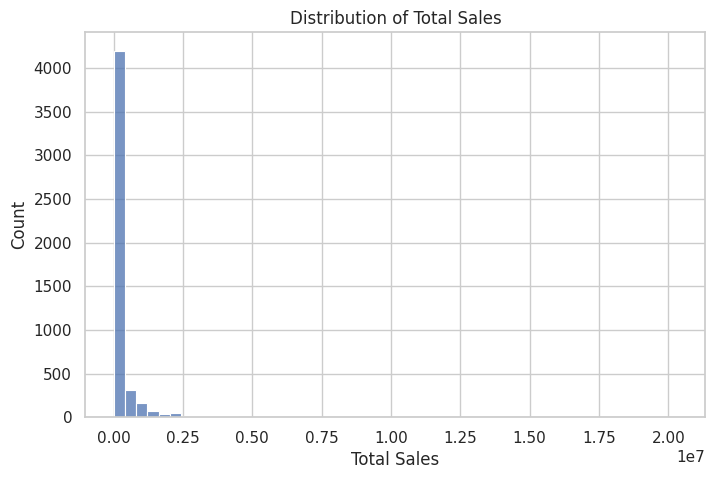

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total Sales'], bins=50)
plt.title("Distribution of Total Sales")
plt.show()

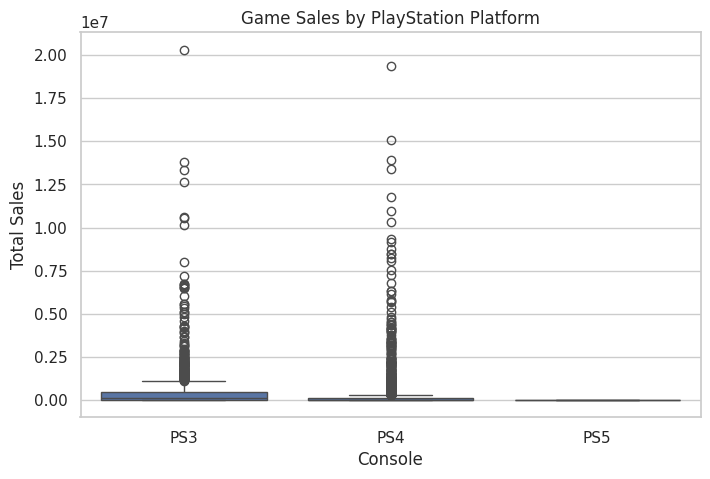

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Console', y='Total Sales', data=df)
plt.title("Game Sales by PlayStation Platform")
plt.show()

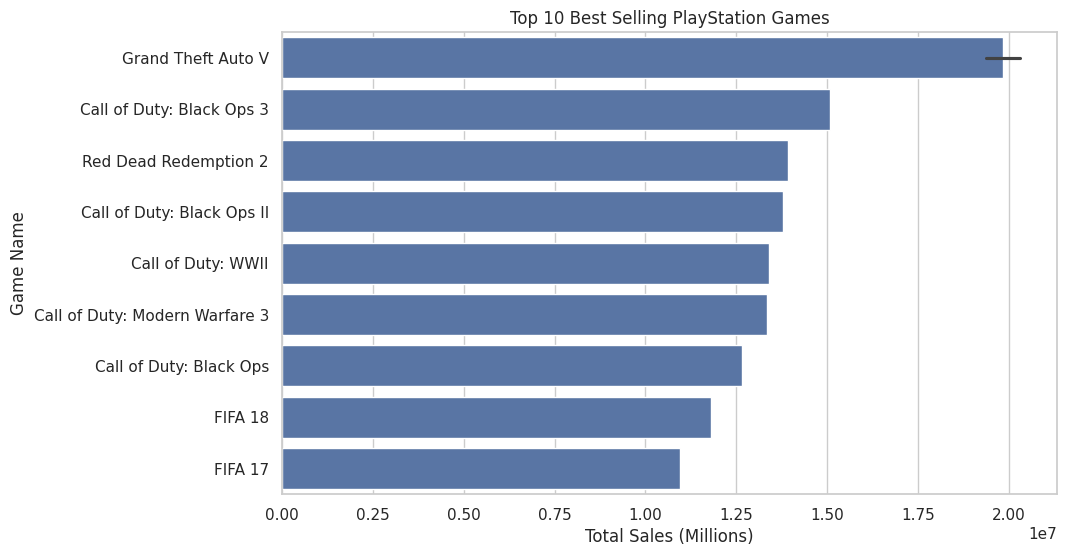

In [10]:
top_games = df.sort_values(by="Total Sales", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="Total Sales", y="Name", data=top_games)
plt.title("Top 10 Best Selling PlayStation Games")
plt.xlabel("Total Sales (Millions)")
plt.ylabel("Game Name")
plt.show()

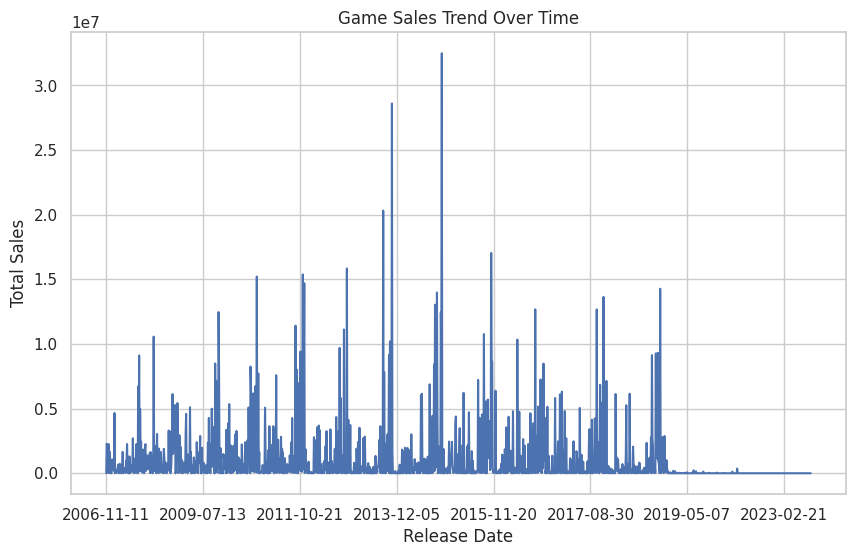

In [11]:
year_sales = df.groupby("Release Date")["Total Sales"].sum()

plt.figure(figsize=(10,6))
year_sales.plot()
plt.title("Game Sales Trend Over Time")
plt.xlabel("Release Date")
plt.ylabel("Total Sales")
plt.show()

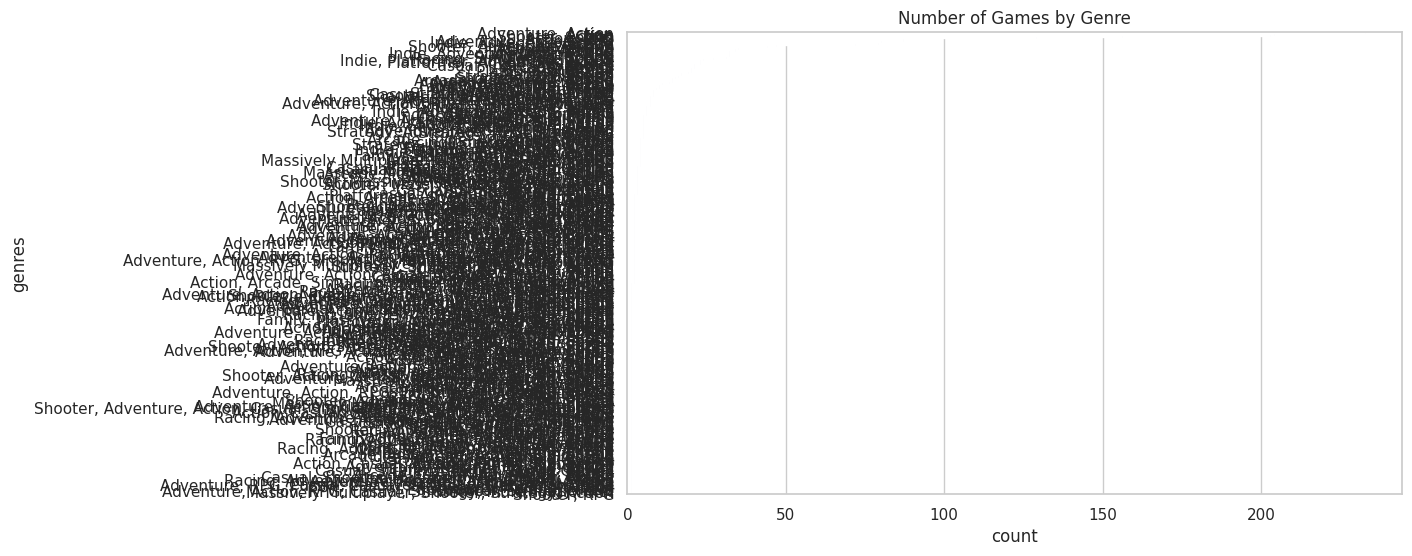

In [12]:
plt.figure(figsize=(10,6))
sns.countplot(y='genres', data=df, order=df['genres'].value_counts().index)
plt.title("Number of Games by Genre")
plt.show()

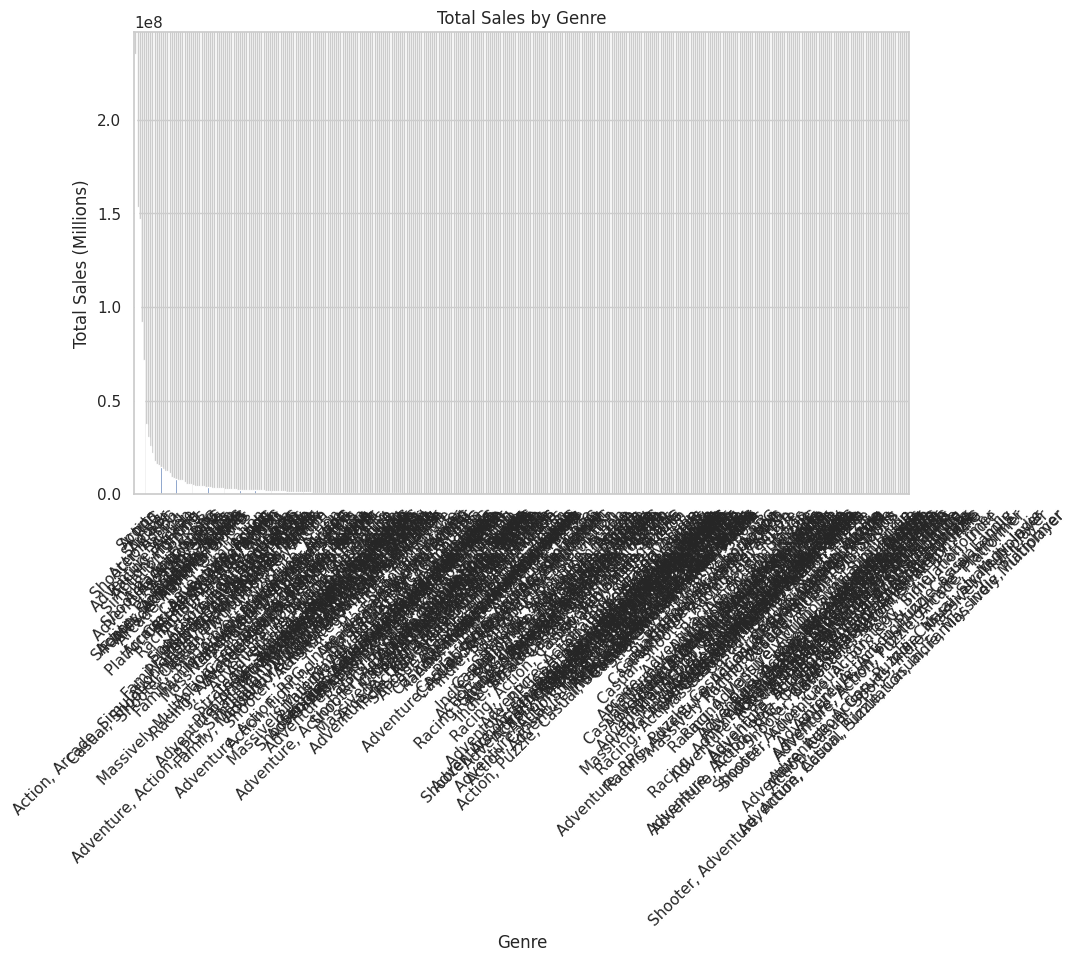

In [13]:
genre_sales = df.groupby("genres")["Total Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
genre_sales.plot(kind="bar")
plt.title("Total Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Total Sales (Millions)")
plt.xticks(rotation=45)
plt.show()

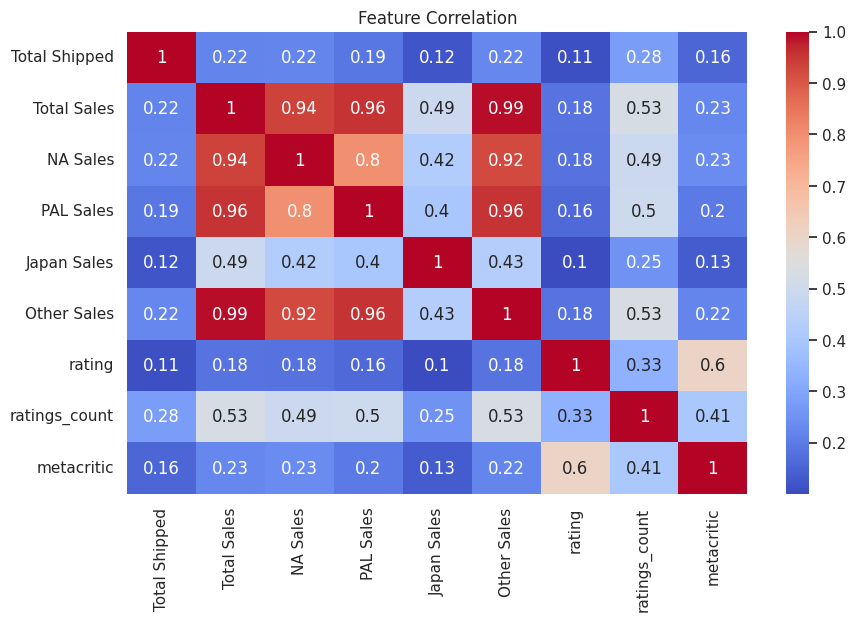

In [14]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [15]:
df.drop_duplicates(inplace=True)

Duplicate rows may distort analysis results and machine learning models, so they are removed.

In [16]:
df = df.dropna()

Rows containing missing values are removed to ensure the dataset remains clean for further analysis.

In [17]:
df['Release Date'] = pd.to_datetime(df['Release Date'])
df['Year'] = df['Release Date'].dt.year

The Release Date column was converted to datetime format and the year was extracted to create a new feature called Year. This allows easier analysis of sales trends over time.

In [18]:
df[['Release Date','Year']].head()

,Release Date,Year
1,2014-11-18,2014
3,2018-10-26,2018
5,2017-11-03,2017
8,2017-09-29,2017
9,2016-09-27,2016


In [19]:
pd.get_dummies(df, columns=['platforms'])

,Game,Console,Name,Publisher,Developer,Total Shipped,Total Sales,NA Sales,PAL Sales,Japan Sales,...,"platforms_PlayStation 5, Xbox Series S/X","platforms_Xbox One, PlayStation 4","platforms_Xbox One, PlayStation 4, Nintendo 3DS, Xbox 360, Wii U","platforms_Xbox One, PlayStation 4, Nintendo Switch","platforms_Xbox One, PlayStation 4, Nintendo Switch, Nintendo 3DS","platforms_Xbox One, PlayStation 4, Nintendo Switch, Xbox 360, PlayStation 3, Wii U","platforms_Xbox One, PlayStation 4, Nintendo Switch, Xbox 360, Wii U","platforms_Xbox One, PlayStation 4, Xbox 360, PlayStation 3","platforms_Xbox One, PlayStation 4, iOS, Android","platforms_Xbox One, PlayStation 4, iOS, Xbox 360, PlayStation 3, Wii U"
1,PS4_Grand Theft Auto V,PS4,Grand Theft Auto V,Rockstar Games,Rockstar North,0.0,19390000.0,6060000.0,9710000.0,600000.0,...,False,False,False,False,False,False,False,False,False,False
3,PS4_Red Dead Redemption 2,PS4,Red Dead Redemption 2,Rockstar Games,Rockstar Games,0.0,13940000.0,5260000.0,6210000.0,210000.0,...,False,False,False,False,False,False,False,False,False,False
5,PS4_Call of Duty: WWII,PS4,Call of Duty: WWII,Activision,Sledgehammer Games,0.0,13400000.0,4670000.0,6210000.0,400000.0,...,False,False,False,False,False,False,False,False,False,False
8,PS4_FIFA 18,PS4,FIFA 18,EA Sports,EA Vancouver,0.0,11800000.0,1270000.0,8640000.0,150000.0,...,False,False,False,False,False,False,False,False,False,False
9,PS4_FIFA 17,PS4,FIFA 17,Electronic Arts,EA Canada,0.0,10940000.0,1260000.0,7950000.0,120000.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4945,PS4_Catherine: Full Body,PS4,Catherine: Full Body,Atlus,Atlus,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4948,PS4_Celeste,PS4,Celeste,Matt Makes Games Inc.,Matt Thorson,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4952,PS4_Chaos on Deponia,PS4,Chaos on Deponia,Daedalic Entertainment,Daedalic Entertainment,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4953,PS4_Chariot,PS4,Chariot,Frima Studio,Frima Studio,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


In [20]:
pd.get_dummies(df, columns=['genres'])

,Game,Console,Name,Publisher,Developer,Total Shipped,Total Sales,NA Sales,PAL Sales,Japan Sales,...,"genres_Strategy, Adventure, RPG, Simulation","genres_Strategy, Indie","genres_Strategy, Indie, Action, Simulation","genres_Strategy, Indie, RPG","genres_Strategy, Indie, Simulation","genres_Strategy, RPG","genres_Strategy, RPG, Simulation","genres_Strategy, Simulation","genres_Strategy, Simulation, Puzzle","genres_Strategy, Sports"
1,PS4_Grand Theft Auto V,PS4,Grand Theft Auto V,Rockstar Games,Rockstar North,0.0,19390000.0,6060000.0,9710000.0,600000.0,...,False,False,False,False,False,False,False,False,False,False
3,PS4_Red Dead Redemption 2,PS4,Red Dead Redemption 2,Rockstar Games,Rockstar Games,0.0,13940000.0,5260000.0,6210000.0,210000.0,...,False,False,False,False,False,False,False,False,False,False
5,PS4_Call of Duty: WWII,PS4,Call of Duty: WWII,Activision,Sledgehammer Games,0.0,13400000.0,4670000.0,6210000.0,400000.0,...,False,False,False,False,False,False,False,False,False,False
8,PS4_FIFA 18,PS4,FIFA 18,EA Sports,EA Vancouver,0.0,11800000.0,1270000.0,8640000.0,150000.0,...,False,False,False,False,False,False,False,False,False,False
9,PS4_FIFA 17,PS4,FIFA 17,Electronic Arts,EA Canada,0.0,10940000.0,1260000.0,7950000.0,120000.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4945,PS4_Catherine: Full Body,PS4,Catherine: Full Body,Atlus,Atlus,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4948,PS4_Celeste,PS4,Celeste,Matt Makes Games Inc.,Matt Thorson,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4952,PS4_Chaos on Deponia,PS4,Chaos on Deponia,Daedalic Entertainment,Daedalic Entertainment,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4953,PS4_Chariot,PS4,Chariot,Frima Studio,Frima Studio,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


Machine learning models require numeric input, so categorical variables are converted into numerical representations using categorical encoding.

In [21]:
print(df.columns)

Index(['Game', 'Console', 'Name', 'Publisher', 'Developer', 'Total Shipped',
       'Total Sales', 'NA Sales', 'PAL Sales', 'Japan Sales', 'Other Sales',
       'Release Date', 'Last Update', 'rating', 'ratings_count', 'metacritic',
       'genres', 'platforms', 'Year'],
      dtype='object')


In [22]:
df.to_csv("playstation_games_preprocessed.csv", index=False)